# Risk Analyzer: Identifying Risks to European Countries

## Why It Matters


## What It Does
The `RiskAnalyzer` class, part of the bigdata-research-tools package, is purpose-built to meet this challenge. Designed for risk analysts, portfolio managers, and investment professionals, it systematically analyzes corporate exposure to specific risk channels using unstructured data from news, earnings calls, and regulatory filings.

## How It Works
RiskAnalyzer combines **hybrid semantic search**, **risk factor taxonomies**, and **structured validation techniques** to deliver:

- **Targeted extraction of risk signals** and supporting evidence from massive unstructured datasets
- **Standardized exposure metrics** to compare risk across firms, sectors, or portfolios
- **Actionable insights** that inform investment strategies and enterprise risk decisions
- **Time-based monitoring** to track how exposure levels shift in response to world events

## A Real-World Use Case


## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

In [4]:
from bigdata_client import Bigdata
from bigdata_client.models.search import DocumentType
import sys
import os
import pandas as pd
from bigdata_client.query import SentimentRange

# Bigdata Research Tools imports
from bigdata_research_tools.workflows.risk_analyzer import RiskAnalyzer
from bigdata_research_tools.workflows.utils import get_scored_df
from src.search_entities import search_by_entities, post_process_dataframe
from src.entity_risk_prompt_labeler import (generate_risk_tree, get_entity_risk_prompt,
                                            get_risk_entity_labeler_prompt, label_search_results)

In [5]:
from bigdata_research_tools.labeler.risk_labeler import RiskLabeler

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [6]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our thematic screening results.

In [7]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/risk_analyzer_cities_results.xlsx"

## Load Credentials

In [8]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
#load_dotenv(script_dir / '.env')
load_dotenv('/home/abouchs/.python_env_var/.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


In [9]:
os.environ["BIGDATA_OTHER_ENTITY_PLACEHOLDER"] = "Other Entity"
os.environ["BIGDATA_TARGET_ENTITY_PLACEHOLDER"] = "Target Entity"

## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [10]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining Your Risk Analysis Parameters

To perform a portfolio risk analysis, we need to define several key parameters:

- **Main Theme** (`main_theme`): The risk scenario to analyze (e.g. US Import Tariffs against China)
- **Focus** (`focus`): The analyst focus that provides an expert perspective on the scenario and helps break it down into risks
-  **Entity Universe** (``entities``): The set of entities to screen
-  **Control Entities** (``control_entities``): The set of entities to be always comentioned with your watchlist (e.g. people, places, organizations, etc)
-  **Time Period** (``start_date`` and ``end_date``): The date range over which to
   run the search
-  **Document Type** (``document_type``): Specify which documents to search over
   (transcripts, filings, news)
-  **Sources** (``sources``): Specify set of sources within a document type, for
   example which news outlets (available via Bigdata API) you wish to
   search over
-  **Fiscal Year** (``fiscal_year``): If the document type is transcripts or
   filings, fiscal year needs to be specified
-  **Model Selection** (``llm_model``): The LLM model used to mindmap the theme
   and label the search result chunks
-  **Rerank Threshold** (``rerank_threshold``): By setting this value, you’re
   enabling the cross-encoder which reranks the results and selects
   those whose relevance is above the percentile you specify (0.7 being
   the 70th percentile). More information on the re-ranker can be found
   [here](https://sdk.bigdata.com/en/latest/how_to_guides/rerank_search.html).
- **Sentiment Range** (``sentiment_range``): The range for chunk sentiment (needs to be a SentimentRange object)
-  **Focus** (``focus``): Specify a focus within the main theme. This will then
   be used in building the LLM generated mindmapper

In [11]:
# ===== Theme Definition =====
main_theme = "Real Estate Refinancing Risks in Global Cities"
analyst_focus="Generate a mind map of current and future risks that global cities can face as related to refinancing."

# ===== Entity Universe =====
entity_names = [
    "London", "New York City", "Beijing", "Dubai", "Hong Kong", "Paris", "Shanghai", "Tokyo",
    "Singapore", "Sydney",
]

entities = [bigdata.knowledge_graph.autosuggest(entity_name, limit=1)[0] for entity_name in entity_names]
control_entities = None

keywords = ['real estate', 'property', 'housing', 'mortgage', 'refinancing', 'loan', 'debt']

# ===== LLM Specification =====
llm_model = "openai::gpt-4o-mini"

# ===== Docs Configuration =====
document_type = DocumentType.NEWS
fiscal_year = None

# ===== Enable/Disable Reranker =====
rerank_threshold = None

# ===== Enable/Disable Sentiment Range =====
sentiment_range = SentimentRange([-1, -0.01])

# ===== Specify Time Range =====
start_date = "2025-01-01"
end_date = "2025-10-03"

In [12]:
entities

[Place(id='0932DC', name='London', volume=None, description='London is the capital city of England and United Kingdom, located in the southeastern part of the country.', entity_type='PLCE', place_type='City', country='United Kingdom', region='England'),
 Place(id='FCF6C7', name='New York City', volume=None, description='New York City is a city located in the United States, in the state of New York.', entity_type='PLCE', place_type='City', country='United States', region='State of New York'),
 Place(id='E04190', name='Beijing', volume=None, description='Beijing is the capital city of China, located in the northern part of the country.', entity_type='PLCE', place_type='City', country='China', region='Beijing Municipality'),
 Place(id='7231AC', name='Dubai', volume=None, description='Dubai is a city located in the UAE, in the northeast of the country.', entity_type='PLCE', place_type='City', country='United Arab Emirates', region='Emirate of Dubai'),
 Place(id='1E4A45', name='Hong Kong Sp

## Mindmap a Theme Taxonomy with Bigdata Research Tools

You can leverage Bigdata Research Tools to generate a comprehensive theme taxonomy with an LLM, breaking down a megatrend into smaller,
well-defined concepts for more targeted analysis.

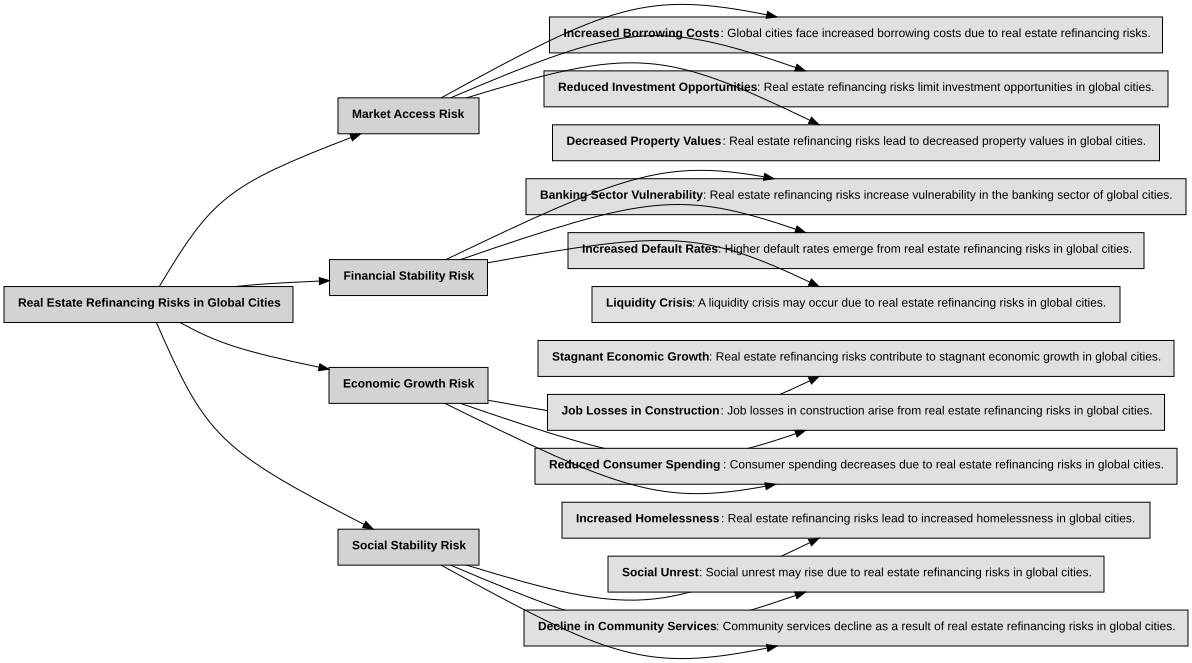

In [13]:
theme_tree = generate_risk_tree(
    main_theme=main_theme,
    analyst_focus=analyst_focus,
    system_prompt=get_entity_risk_prompt(main_theme, analyst_focus).strip(),
)

theme_tree.visualize()

The taxonomy tree includes descriptive sentences that explicitly connect each sub-theme back to the main theme, ensuring all search results remain contextually relevant to our central trend.

In [14]:
node_summaries = list(theme_tree.get_terminal_label_summaries().values())
labels = list(theme_tree.get_terminal_label_summaries().keys())

In [15]:
node_summaries

['Global cities face increased borrowing costs due to real estate refinancing risks.',
 'Real estate refinancing risks limit investment opportunities in global cities.',
 'Real estate refinancing risks lead to decreased property values in global cities.',
 'Real estate refinancing risks increase vulnerability in the banking sector of global cities.',
 'Higher default rates emerge from real estate refinancing risks in global cities.',
 'A liquidity crisis may occur due to real estate refinancing risks in global cities.',
 'Real estate refinancing risks contribute to stagnant economic growth in global cities.',
 'Job losses in construction arise from real estate refinancing risks in global cities.',
 'Consumer spending decreases due to real estate refinancing risks in global cities.',
 'Real estate refinancing risks lead to increased homelessness in global cities.',
 'Social unrest may rise due to real estate refinancing risks in global cities.',
 'Community services decline as a result 

## Retrieve Content using Bigdata’s Search Capabilities

With the theme taxonomy and screening parameters, you can leverage the
Bigdata API to run a search on news or company transcripts. We need to define 3
more parameters for searching:

-  **Frequency** (``freq``): The frequency of the date ranges to search over.
   Supported values:

   -  `Y`: Yearly intervals.
   -  `M`: Monthly intervals.
   -  `W`: Weekly intervals.
   -  `D`: Daily intervals. Defaults to `3M`.

-  **Document Limit** (``document_limit``): The maximum number of documents to
   return per query to Bigdata API.
-  **Batch Size** (``batch_size``): The number of entities to include in a
   single batched query.

In [ ]:
freq = "M"
document_limit = 20
batch_size = 1

In [ ]:
df_sentences = search_by_entities(entities=entities,
    sentences=node_summaries,
    keywords=keywords,
    start_date=start_date,
    end_date=end_date,
    scope=document_type,
    control_entities=control_entities,
    sources=None,
    fiscal_year=None,
    freq=freq,
    sentiment_range=sentiment_range,
    document_limit=document_limit,
    batch_size=batch_size,
    enhance_sentiment=False
)

Running 96 searches (24 queries over 4 date ranges)
Example query:
And(Similarity('Real estate refinancing risks lead to increased homelessness in global cities.'), Or(Entity('0932DC'), Place(id='FCF6C7', name='New York City', volume=None, description='New York City is a city located in the United States, in the state of New York.', entity_type='PLCE', place_type='City', country='United States', region='State of New York'), Place(id='E04190', name='Beijing', volume=None, description='Beijing is the capital city of China, located in the northern part of the country.', entity_type='PLCE', place_type='City', country='China', region='Beijing Municipality'), Place(id='7231AC', name='Dubai', volume=None, description='Dubai is a city located in the UAE, in the northeast of the country.', entity_type='PLCE', place_type='City', country='United Arab Emirates', region='Emirate of Dubai'), Place(id='1E4A45', name='Hong Kong Special Administrative Region', volume=None, description='The Hong Kong Sp

Querying Bigdata...: 100%|██████████| 96/96 [00:25<00:00,  3.76it/s]

Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10


Handling requests throttle. Retries attempted: 10

Processing news results...: 100%|██████████| 960/960 [00:00<00:00, 1459.79it/s]

## Label the Results

Use an LLM to analyze each text chunk and determine its relevance to the sub-themes. Any chunks which aren't explicitly linked to our main theme will be filtered out.

In [19]:
labels = list(theme_tree.get_terminal_label_summaries().keys())

In [20]:
labeler = RiskLabeler(llm_model=llm_model, label_prompt=get_risk_entity_labeler_prompt(main_theme, labels).strip())
df, df_labels = label_search_results(
        df_sentences = df_sentences,
        terminal_labels = labels,
        risk_tree = theme_tree,
        labeler = labeler,
        additional_prompt_fields = ['headline'],
        main_theme = main_theme,)

Querying an LLM...: 100%|██████████| 464/464 [00:30<00:00, 15.43it/s]

Including entity sentiment columns in export


## Assess Thematic Exposure Across Your Entities

We’ll look at the top 10 most exposed companies to our main theme. The function `get_scored_df` will calculate the composite
thematic score, summing up the scores across the sub-themes for each
entity (`df_entity`).

In [23]:
df_entity = pd.DataFrame()

df_entity = get_scored_df(
    df_labels, index_columns=["Entity", "Country"], pivot_column="Sub-Scenario"
)

In [24]:
import numpy as np
def exponential_smoothing(x,decay):
    epw = np.exp(-(np.arange(len(x),0,-1) - 1) / decay)
    return np.sum(x*epw)

In [25]:
from scipy.ndimage import gaussian_filter1d
def volume_z_score(x):
    mean = x.mean()
    std = x.std()
    if std == 0:
        return 0
    else:
        zscore = (x - mean) / std

    # Apply smoothing using Gaussian filter
    smoothed_data = gaussian_filter1d(zscore.fillna(0).values, sigma=2)
    return pd.Series(smoothed_data, index=x.index)

In [ ]:
from itertools import product
df_temp = df_labels.groupby(["Date", "Entity"]).agg({"Sentiment": "mean", 'Entity Sentiment':'mean', 'Entity Text Sentiment':'mean', 'Document ID':'nunique'}).reset_index()

df_temp['Date'] = pd.to_datetime(df_temp['Date'])
fullgrid = pd.DataFrame(list(product(pd.date_range(start=start_date, end=end_date, freq='D'), df_labels['Entity'].unique())), columns=['Date', 'Entity'])

daily_sentiment = pd.merge(fullgrid, df_temp, on=['Date', 'Entity'], how='left')
daily_sentiment['Avg_Sentiment'] = daily_sentiment['Sentiment'].fillna(0)
daily_sentiment['Volume'] = daily_sentiment['Document ID'].fillna(0)

if 'Entity Sentiment' in daily_sentiment.columns:
    daily_sentiment['Avg_Entity_Sentiment'] = daily_sentiment['Entity Sentiment'].fillna(0)
    daily_sentiment['Avg_Entity_Text_Sentiment'] = daily_sentiment['Entity Text Sentiment'].fillna(0)

daily_sentiment = daily_sentiment.sort_values(by=['Entity', 'Date'])

In [ ]:
daily_sentiment['avg_sent_smoothed'] = daily_sentiment.groupby('Entity')['Avg_Sentiment'].transform(lambda x: x.rolling(window=180, min_periods=1).apply(exponential_smoothing, kwargs={'decay': 30}))

##calculate QoQ sentiment.

if 'Entity Sentiment' in daily_sentiment.columns:

    daily_sentiment['avg_entitysent_smoothed'] = daily_sentiment.groupby('Entity')['Avg_Entity_Sentiment'].transform(lambda x: x.rolling(window=180, min_periods=1).apply(exponential_smoothing, kwargs={'decay': 90}))
    daily_sentiment['avg_entitytextsent_smoothed'] = daily_sentiment.groupby('Entity')['Avg_Entity_Text_Sentiment'].transform(lambda x: x.rolling(window=180, min_periods=1).apply(exponential_smoothing, kwargs={'decay': 90}))

In [28]:
daily_sentiment['volume_zscore'] = daily_sentiment.groupby('Entity')['Volume'].transform(lambda x: volume_z_score(x))

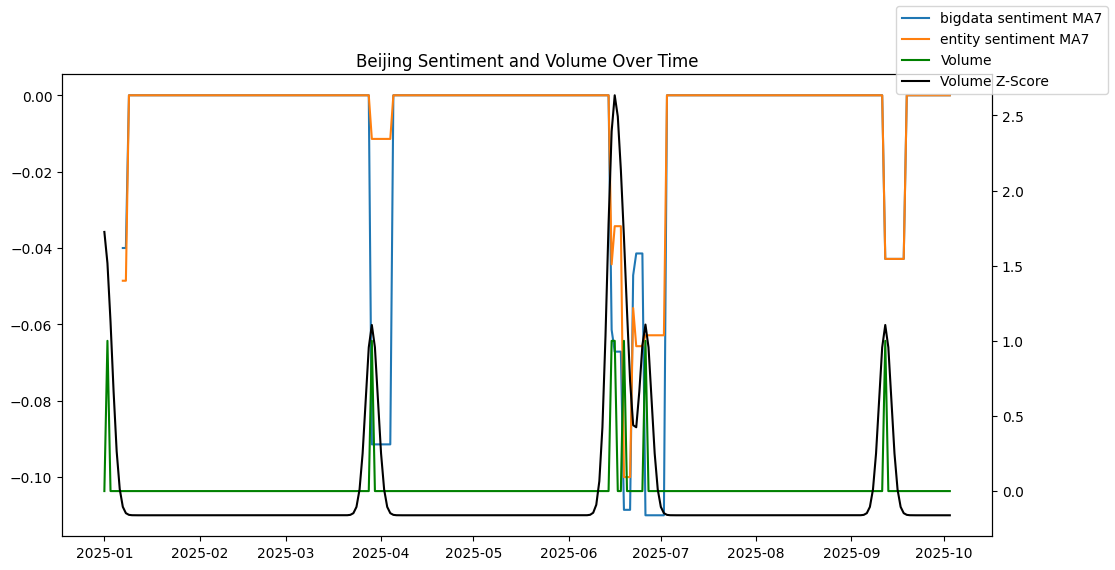

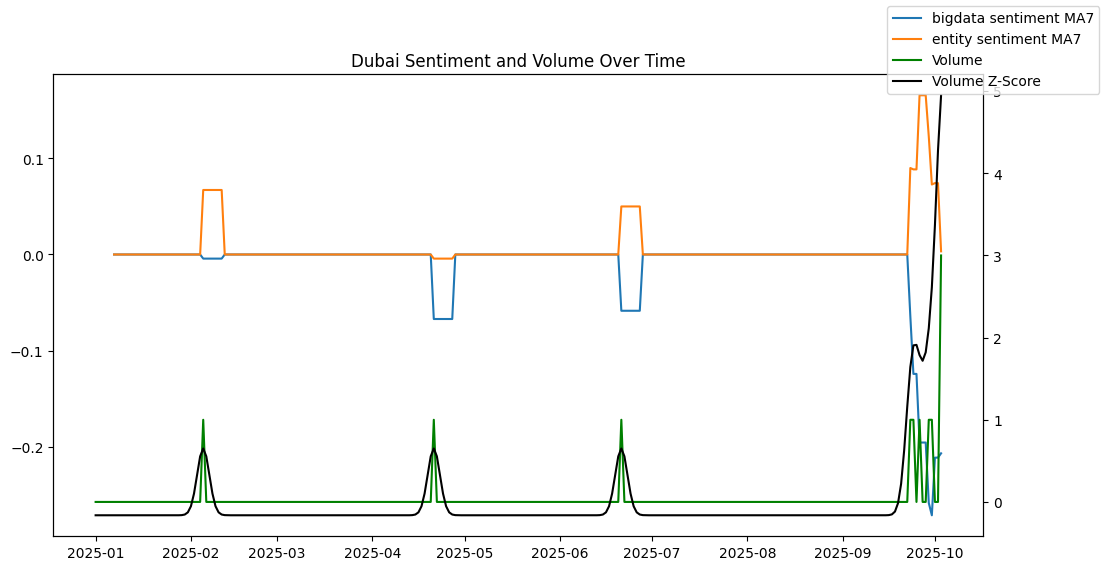

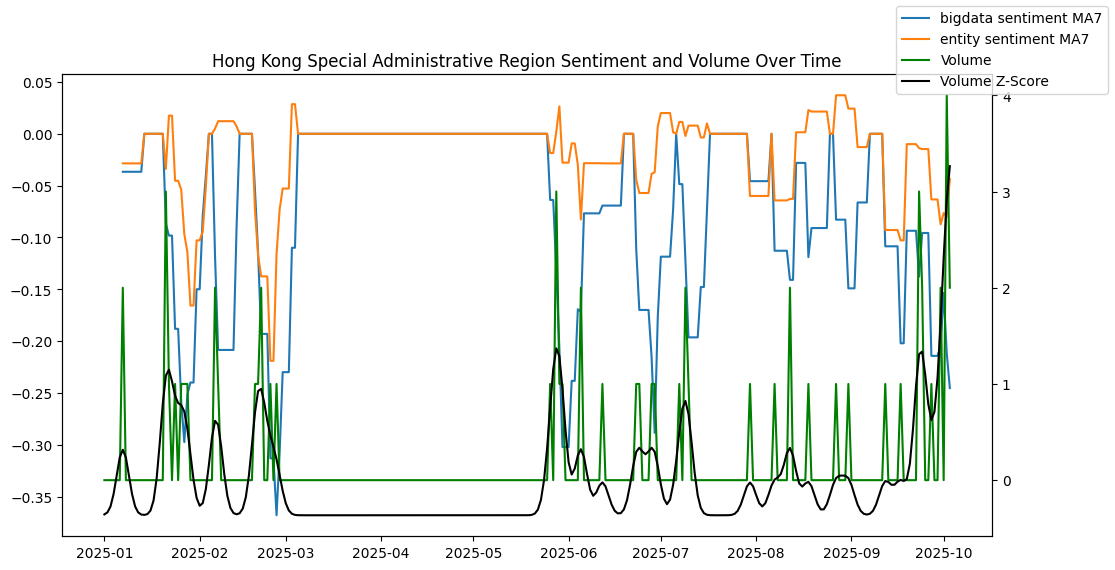

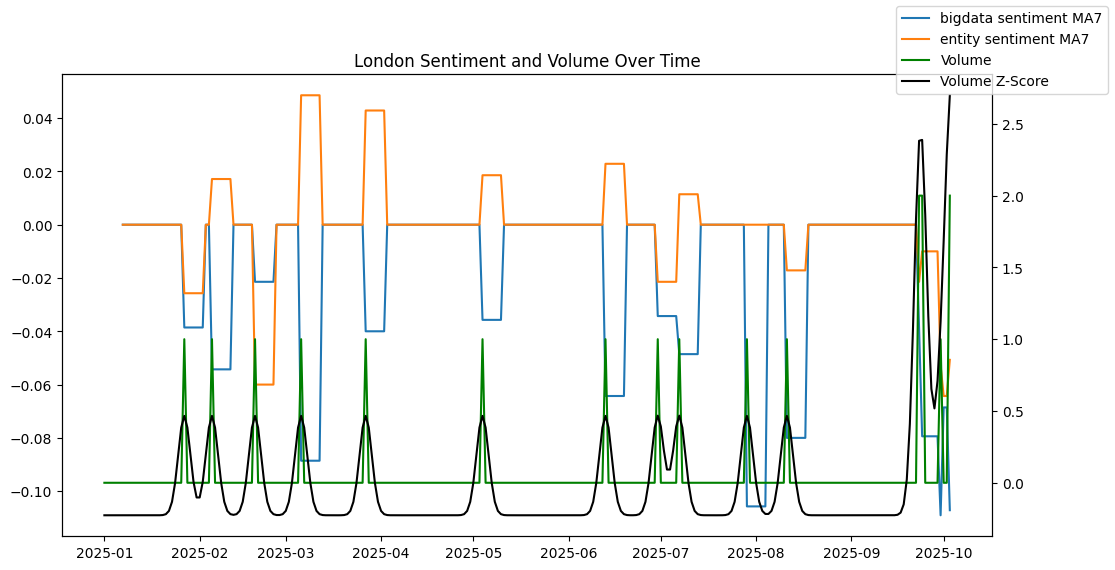

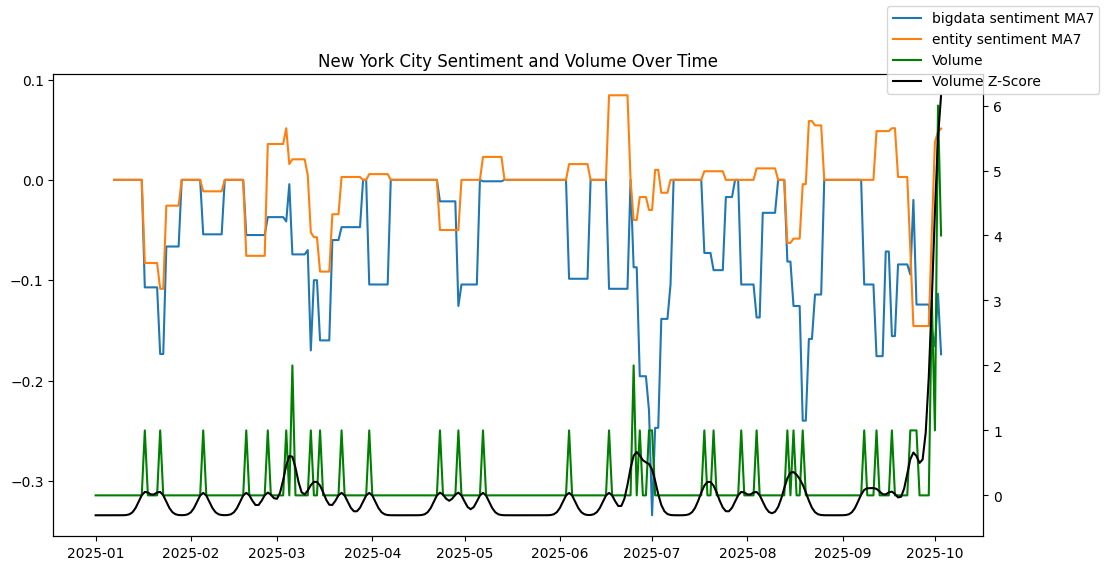

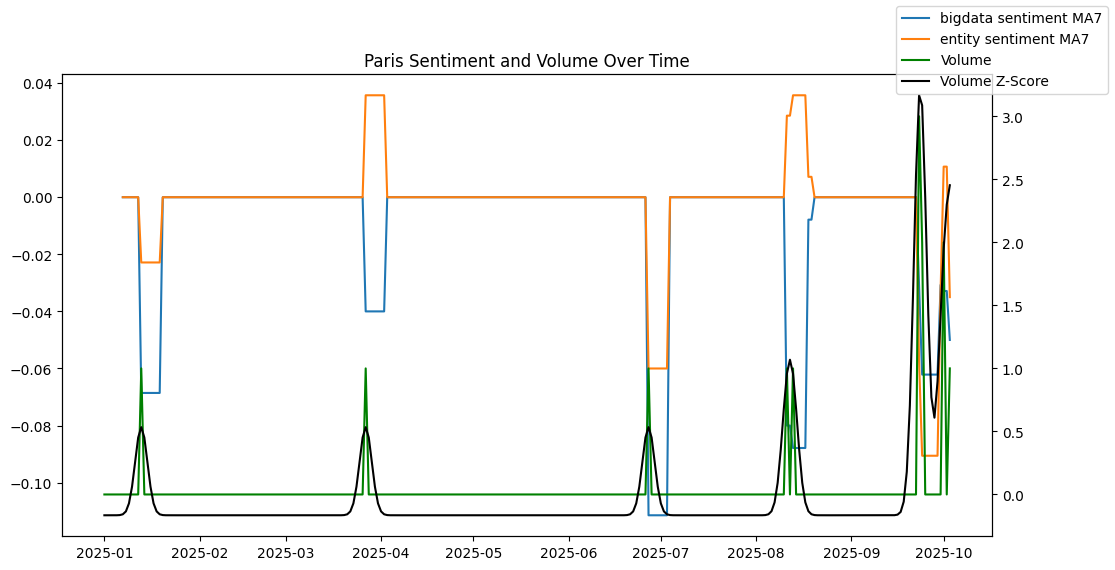

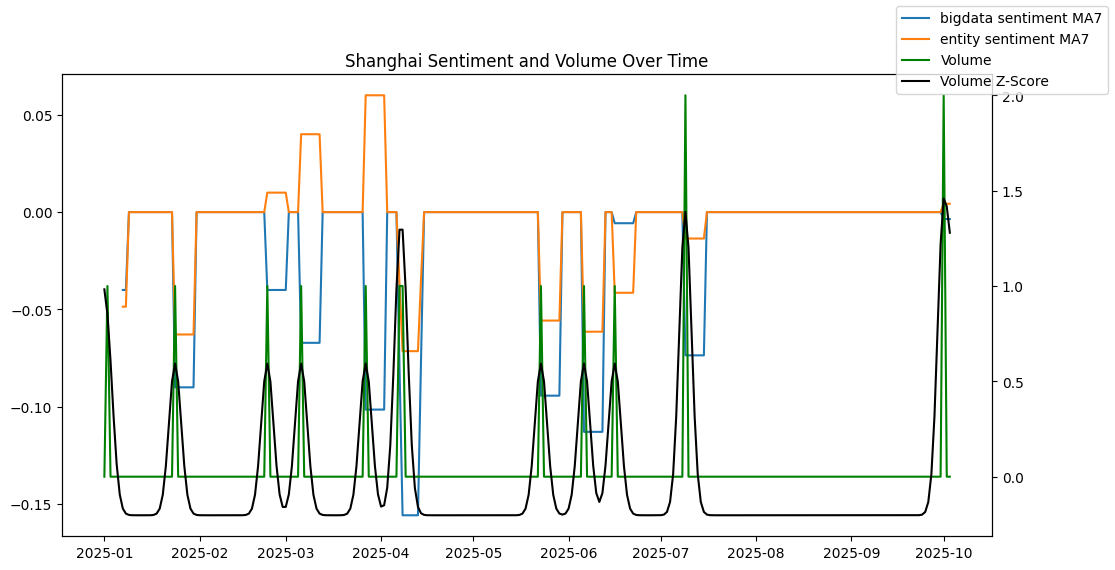

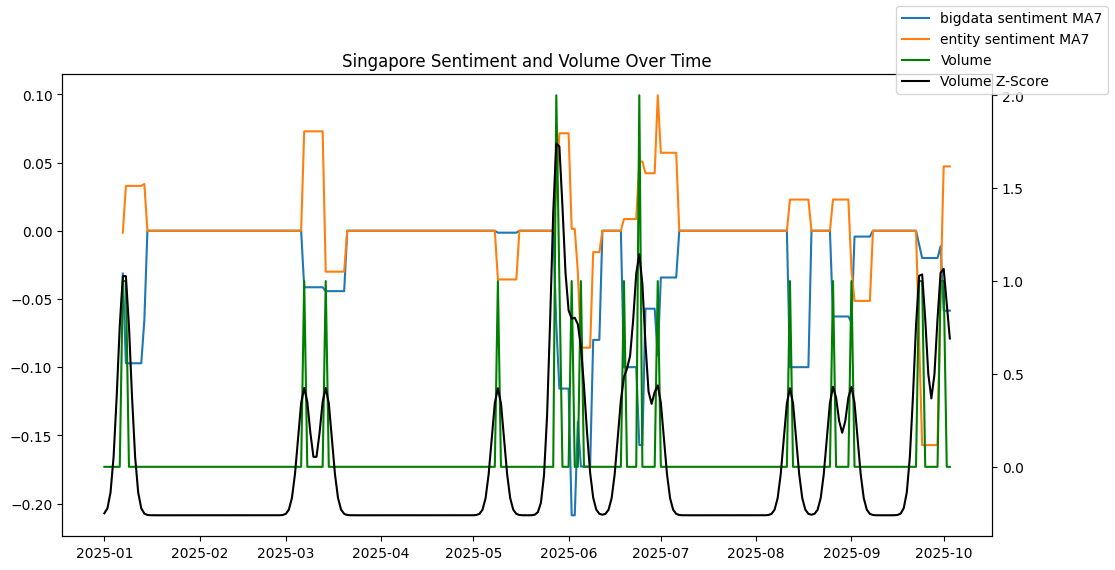

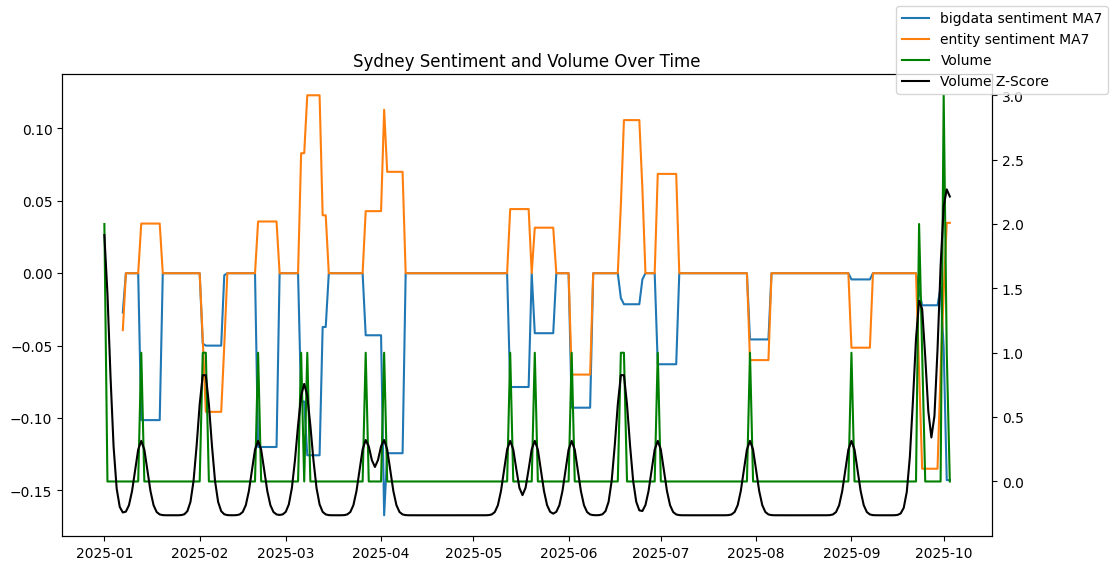

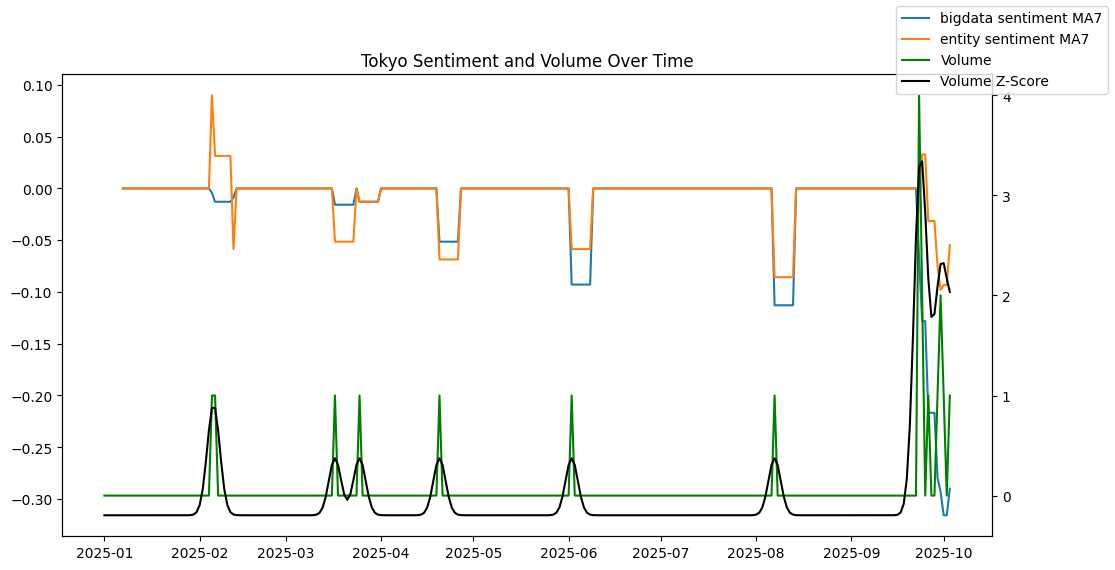

In [ ]:
import matplotlib.pyplot as plt

for entity in daily_sentiment['Entity'].unique():
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    entity_data = daily_sentiment[daily_sentiment['Entity'] == entity].sort_values("Date")
    ax.plot(entity_data["Date"], entity_data["Avg_Sentiment"].rolling(window=7).mean(), label='bigdata sentiment MA7')
    #ax.plot(entity_data["Date"], entity_data["Avg_Entity_Sentiment"].rolling(window=7).mean(), label='entity sentiment MA7')
    #ax.plot(entity_data["Date"], entity_data["avg_sent_smoothed"], label='bigdata sentiment')
    #ax.plot(entity_data["Date"], entity_data["avg_entitysent_smoothed"], label='entity sentiment')
    ax1 = ax.twinx()
    ax1.plot(entity_data["Date"], entity_data["Volume"], label='Volume', color='green')
    #ax1.plot(entity_data["Date"], entity_data["volume_zscore"], label='Volume Z-Score', color='black')
    fig.legend()
    
    ax.set_title(f"{entity} Sentiment and Volume Over Time")

In [68]:
daily_sentiment.columns

Index(['Date', 'Entity', 'Sentiment', 'Entity Sentiment',
       'Entity Text Sentiment', 'Document ID', 'Avg_Sentiment',
       'Avg_Entity_Sentiment', 'Avg_Entity_Text_Sentiment', 'Volume',
       'avg_sent_smoothed', 'avg_entitysent_smoothed',
       'avg_entitytextsent_smoothed', 'volume_zscore'],
      dtype='object')

In [ ]:
from src.report_generator import SummaryGenerator
from src.narrative_dashboard import display_dashboard, summarize_narratives, get_narrative_windows

In [119]:
summarizer = SummaryGenerator(llm_model=llm_model, temperature=0)

In [120]:
peak_coverage_windows = get_narrative_windows(daily_sentiment, df_labels, sentiment_cols={'average':'Avg_Sentiment', 'smoothed':'avg_sent_smoothed'}, min_max='min', lookback_days=30)

In [122]:
entity_narratives = summarize_narratives(df_labels, entities, summarizer, peak_coverage_windows)

Processing entity: Beijing
  Processing window type: volume with 1 records
  Processing window type: sentiment with 2 records
Completed processing for entity: Beijing

Processing entity: Hong Kong Special Administrative Region
  Processing window type: volume with 18 records
  Processing window type: sentiment with 22 records
Completed processing for entity: Hong Kong Special Administrative Region

Processing entity: London
  Processing window type: volume with 3 records
  Processing window type: sentiment with 2 records
Completed processing for entity: London

Processing entity: New York City
  Processing window type: volume with 2 records
  Processing window type: sentiment with 3 records
Completed processing for entity: New York City

Processing entity: Paris
  Processing window type: volume with 1 records
  Processing window type: sentiment with 1 records
Completed processing for entity: Paris

Processing entity: Shanghai
  Processing window type: volume with 3 records
  Processing

Entity: Beijing
Highest Volume: 1 on 2025-01-26
Most Negative Sentiment: -0.54 on 2025-08-12


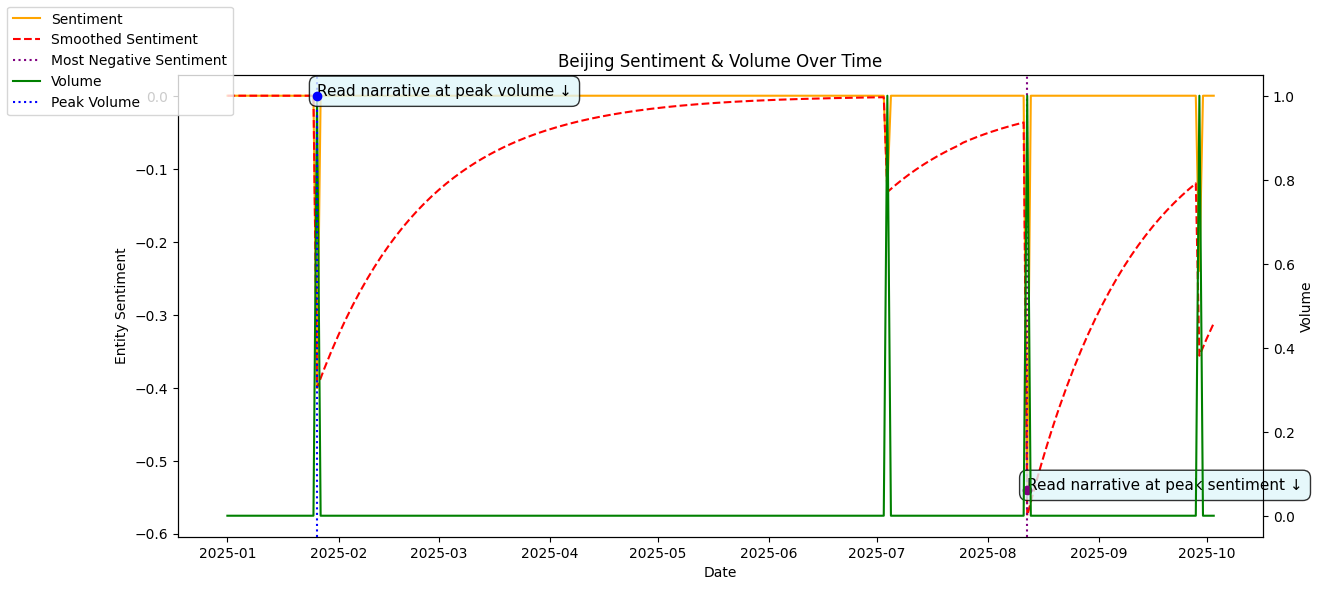

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Hong Kong Special Administrative Region
Highest Volume: 4 on 2025-07-09
Most Negative Sentiment: -0.78 on 2025-07-17


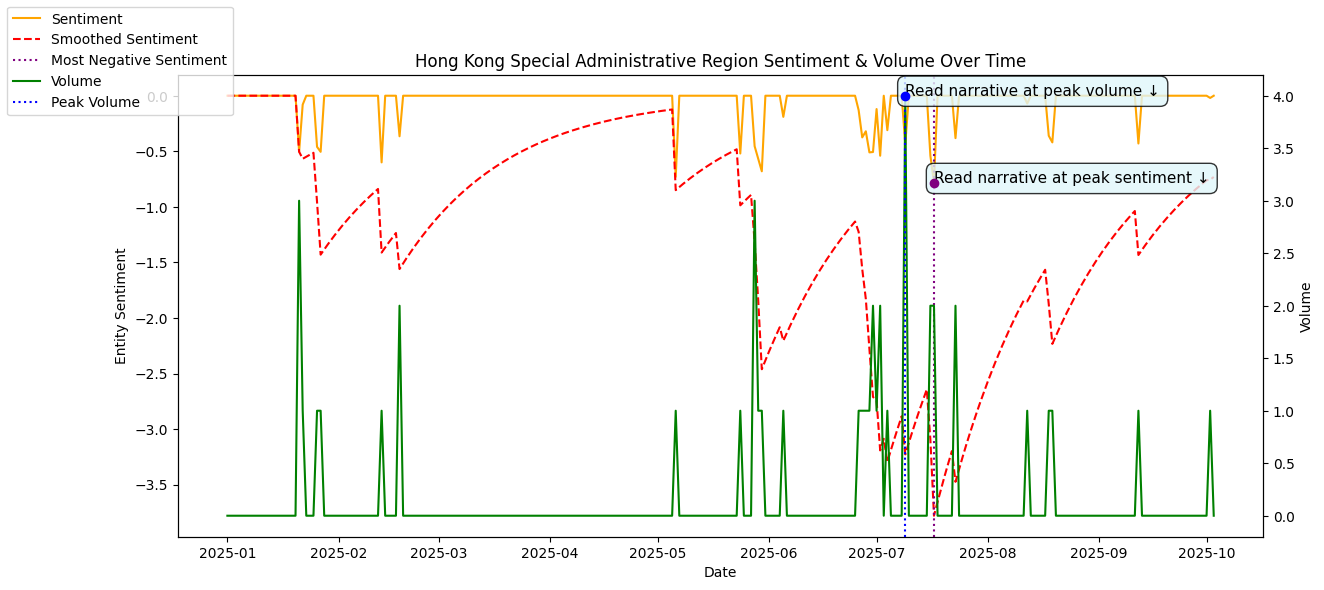

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: London
Highest Volume: 3 on 2025-07-23
Most Negative Sentiment: -0.83 on 2025-10-01


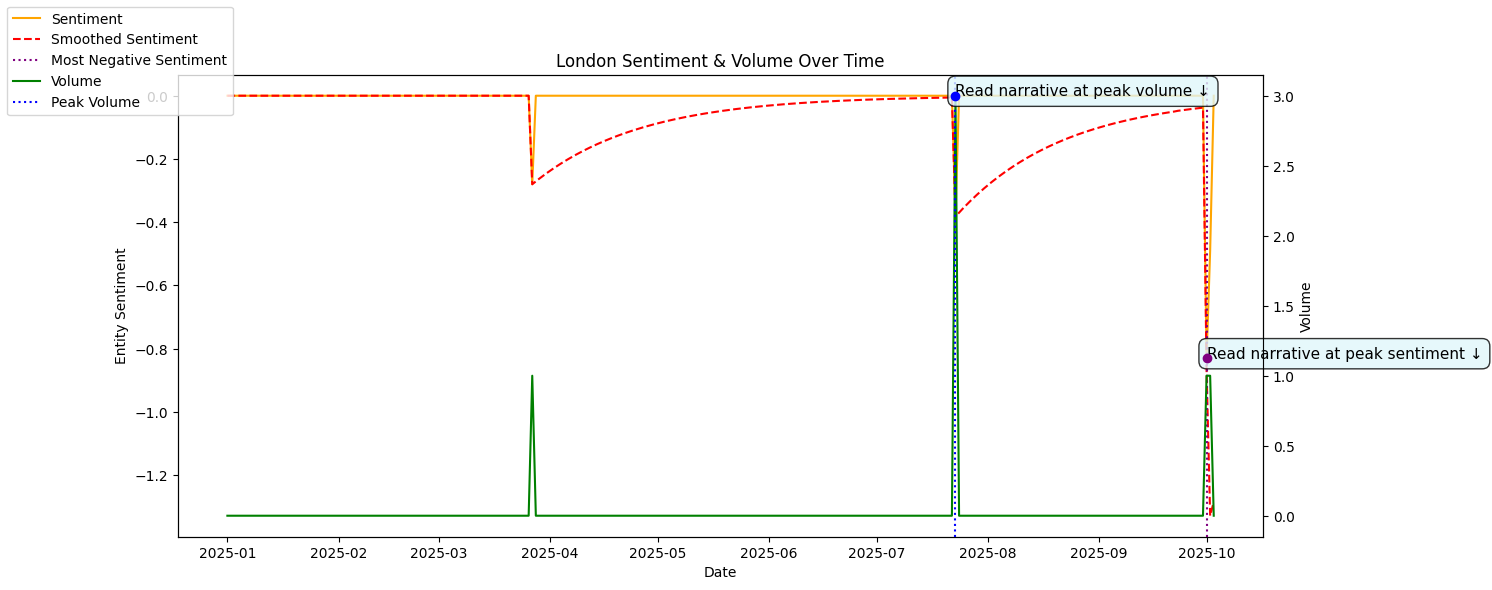

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: New York City
Highest Volume: 2 on 2025-10-01
Most Negative Sentiment: -0.77 on 2025-02-19


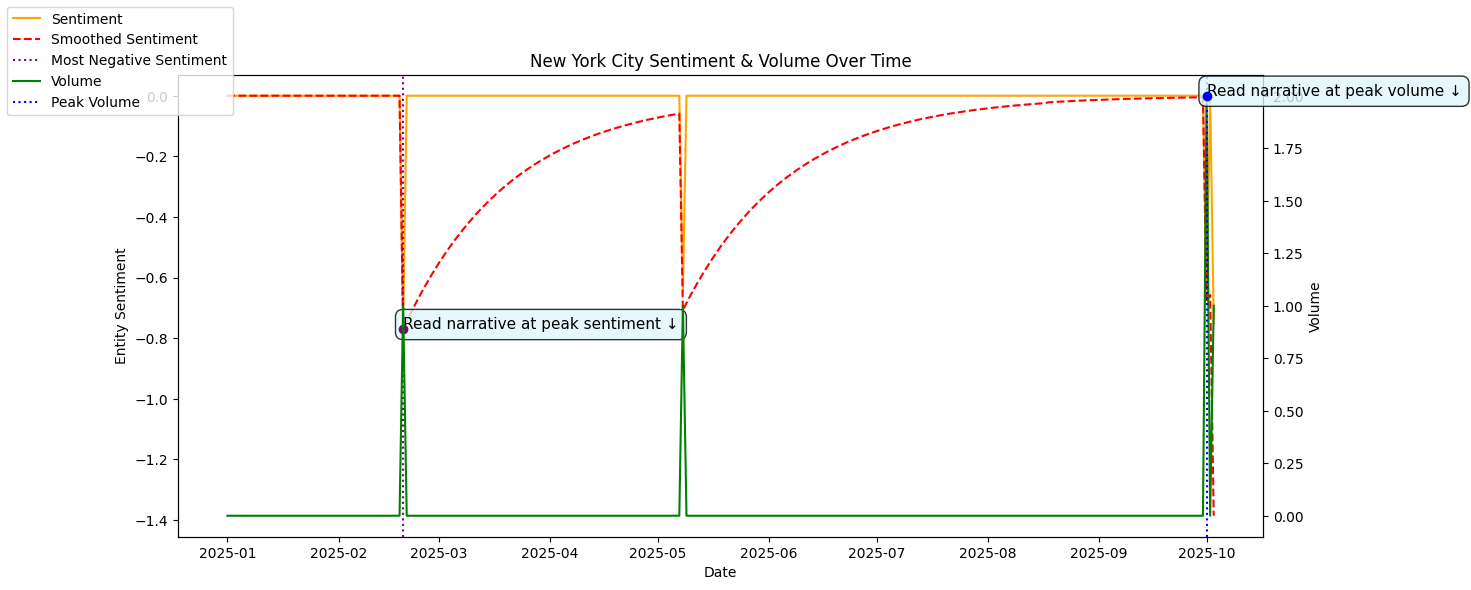

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Paris
Highest Volume: 1 on 2025-03-27
Most Negative Sentiment: -0.28 on 2025-03-27


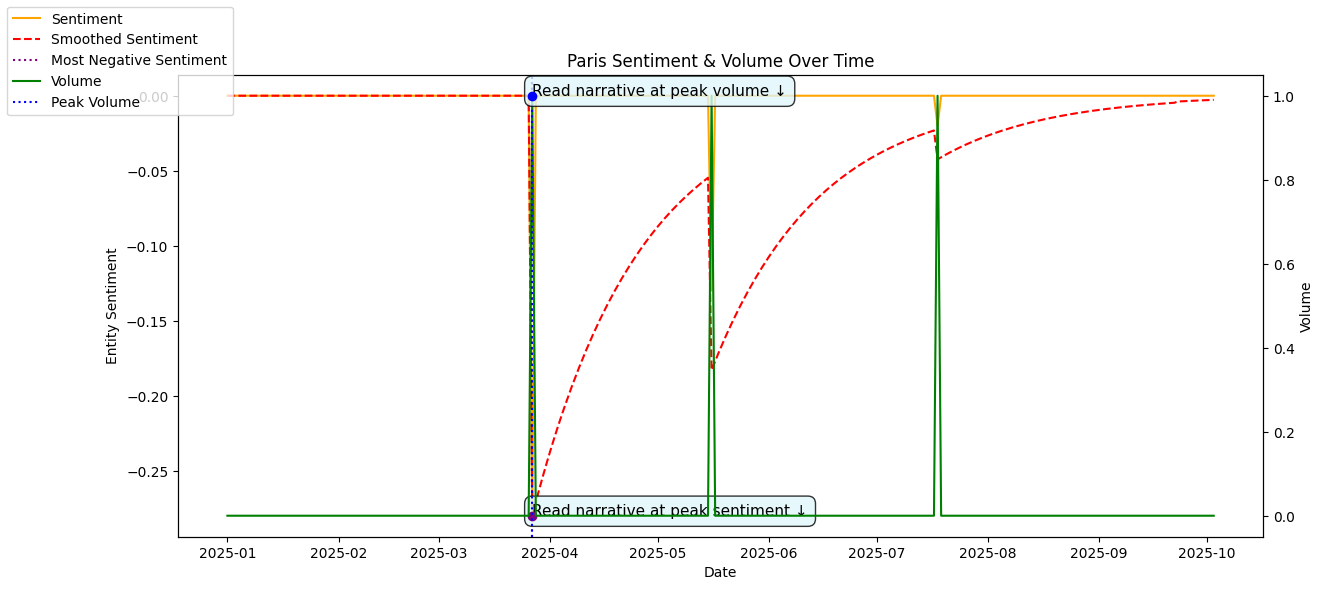

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Shanghai
Highest Volume: 3 on 2025-07-09
Most Negative Sentiment: -0.43 on 2025-07-09


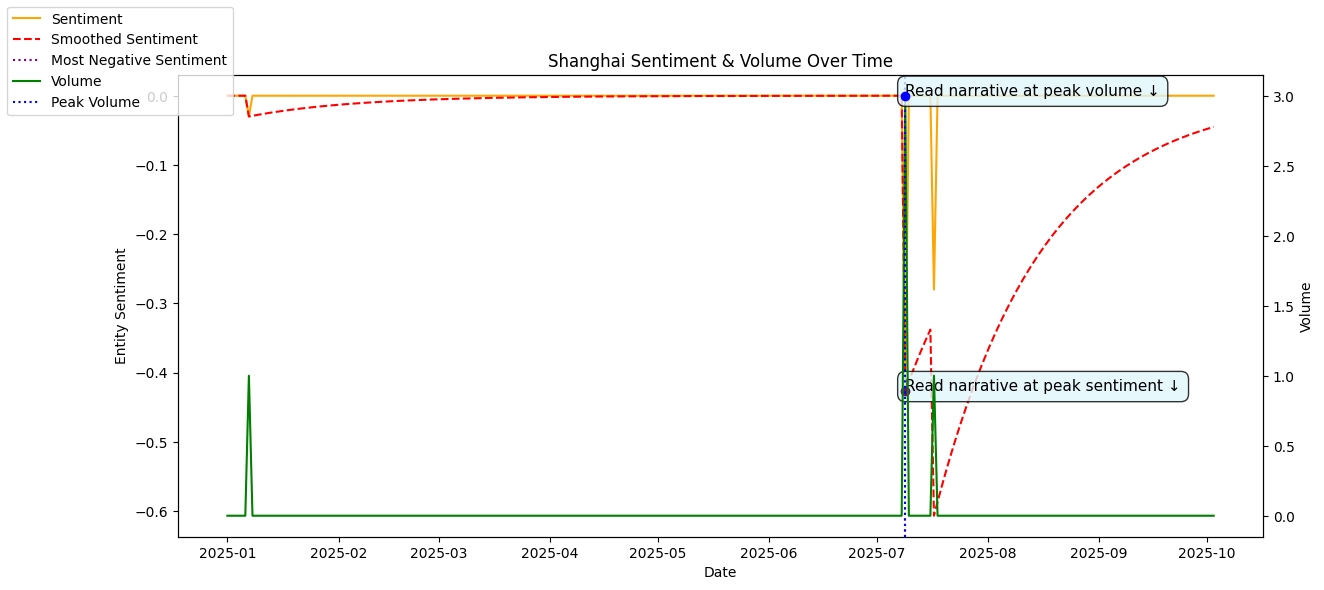

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Singapore
Highest Volume: 2 on 2025-05-28
Most Negative Sentiment: -0.65 on 2025-05-08


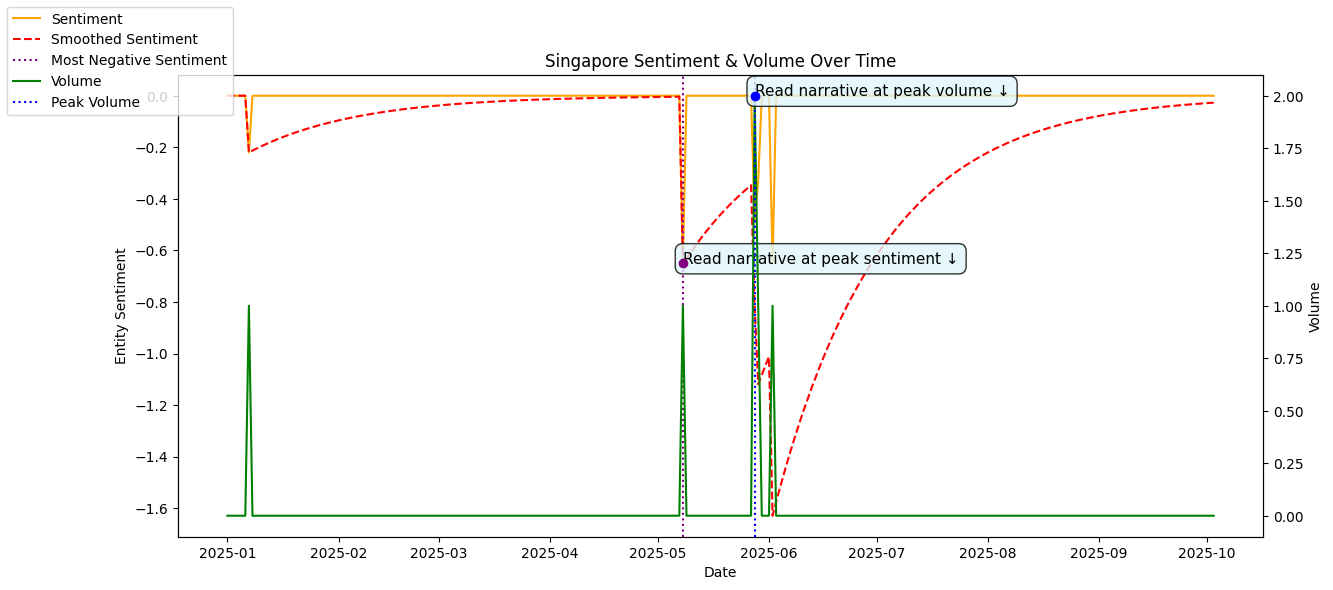

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Sydney
Highest Volume: 2 on 2025-02-17
Most Negative Sentiment: -0.80 on 2025-04-07


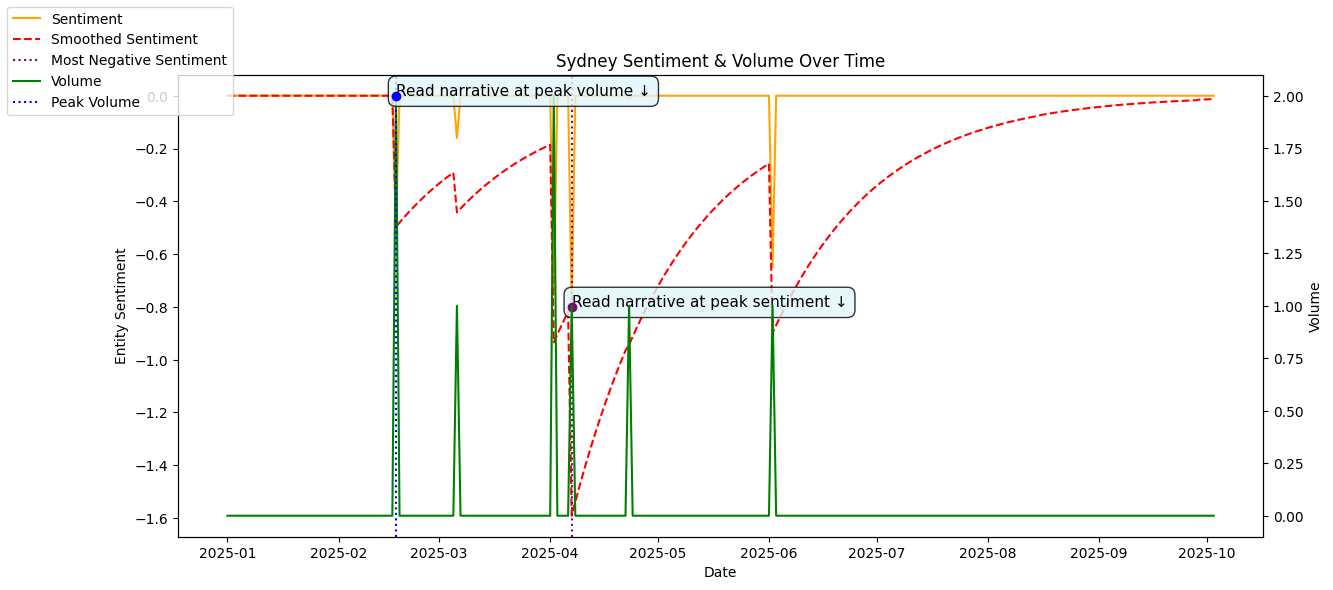

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

Entity: Tokyo
Highest Volume: 1 on 2025-01-14
Most Negative Sentiment: -0.65 on 2025-06-02


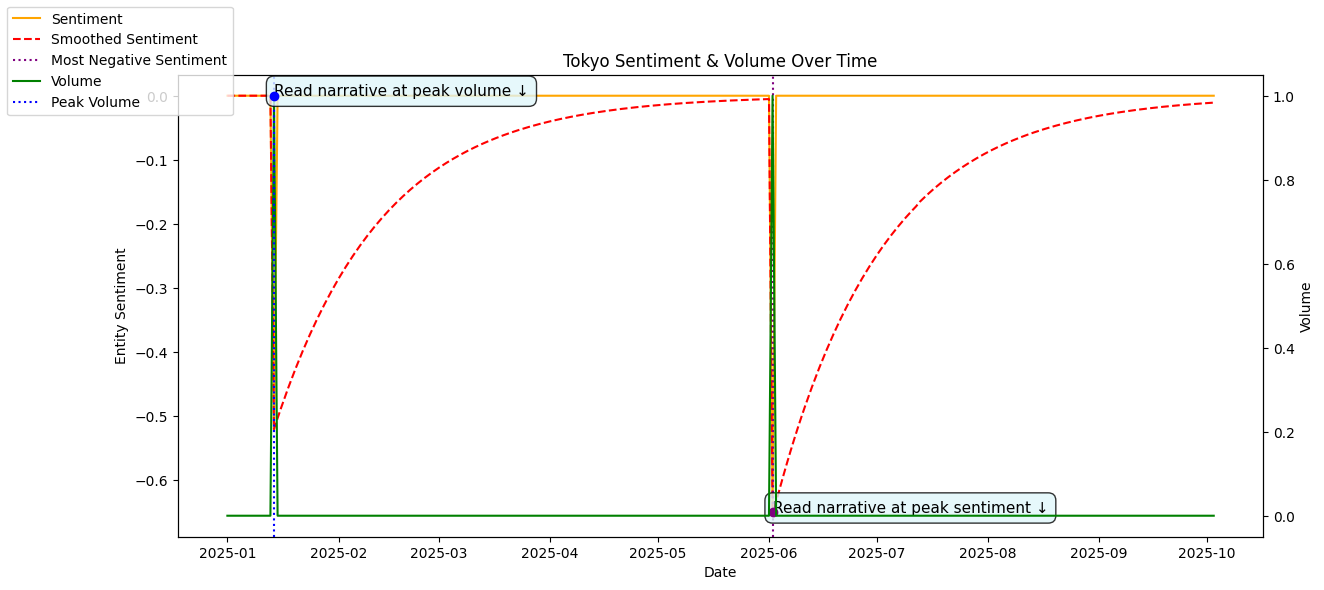

Accordion(children=(Output(), Output()), titles=('Peak Volume Narrative', 'Most Negative Sentiment Narrative')…

In [128]:
for entity in entity_narratives.keys():

    display_dashboard(daily_sentiment, entity, {'average':'Avg_Sentiment', 'smoothed':'avg_sent_smoothed'}, narratives=entity_narratives)


Displaying Entity Risk Exposure Dashboard...

Entity Risk Exposure Heatmap (Raw Scores):

Total Entity Risk Exposure Score:

Top Risk Exposures by Entity:

Risk Exposure Scores across Sub-Scenarios:


/home/abouchs/git/bigdata-cookbook/Screener_for_Entities/src/visualization_tool.py:736: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



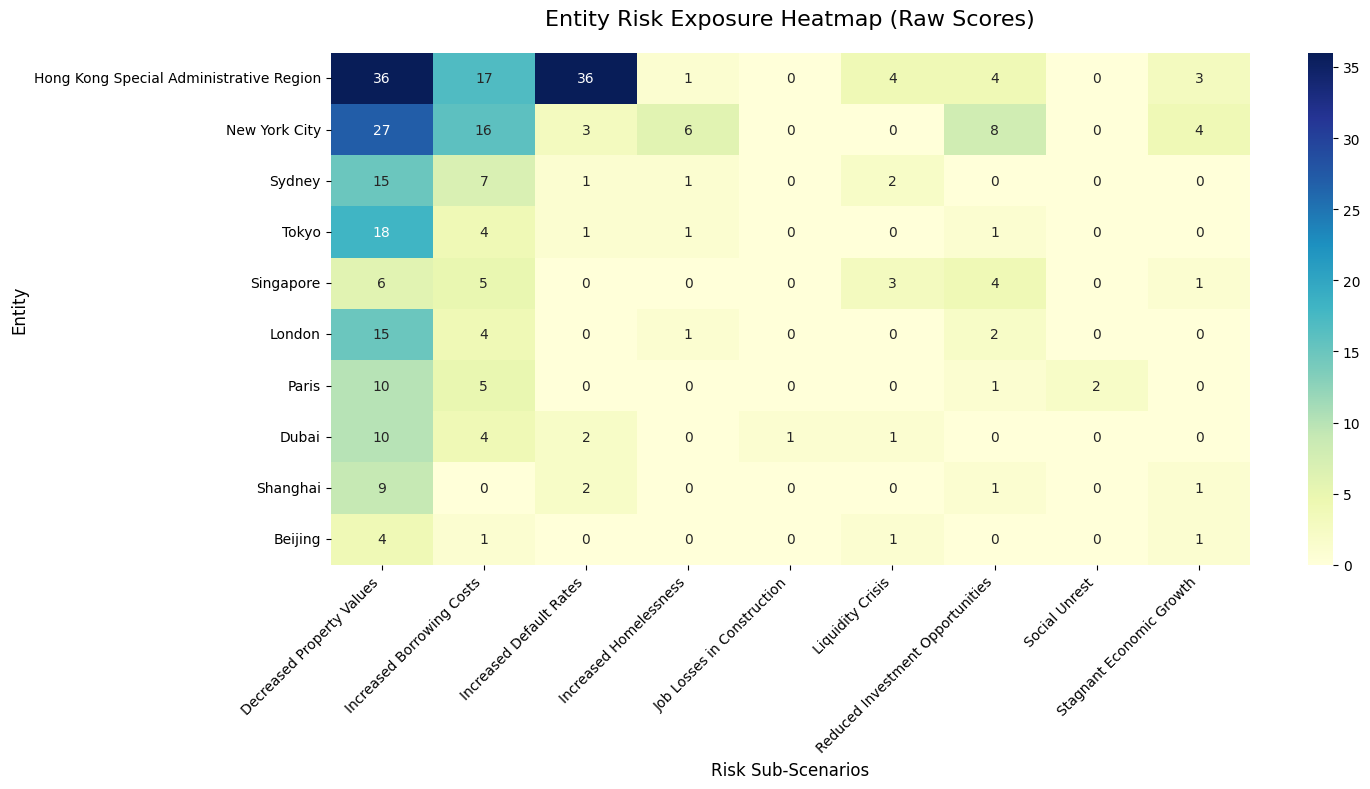

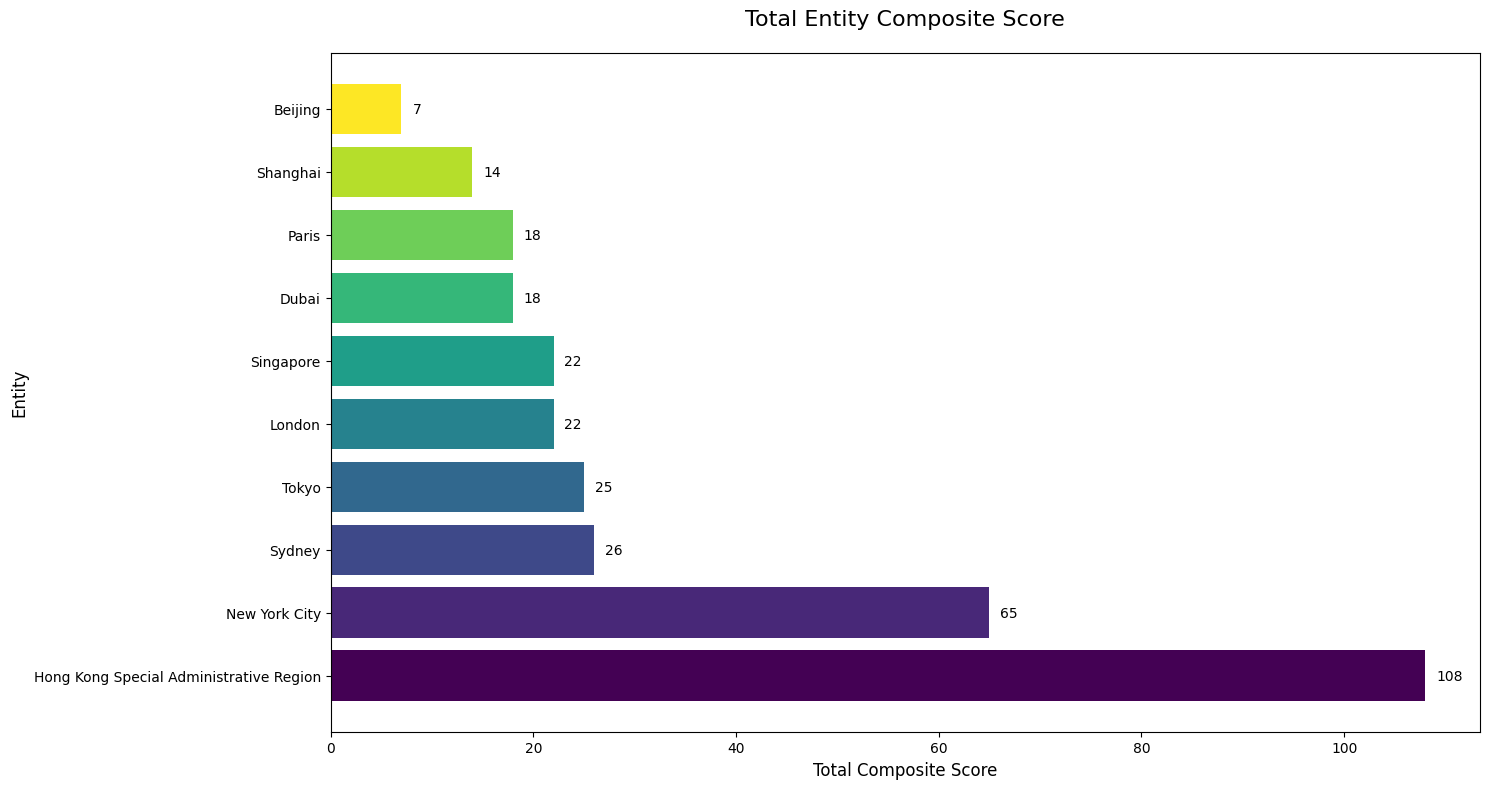

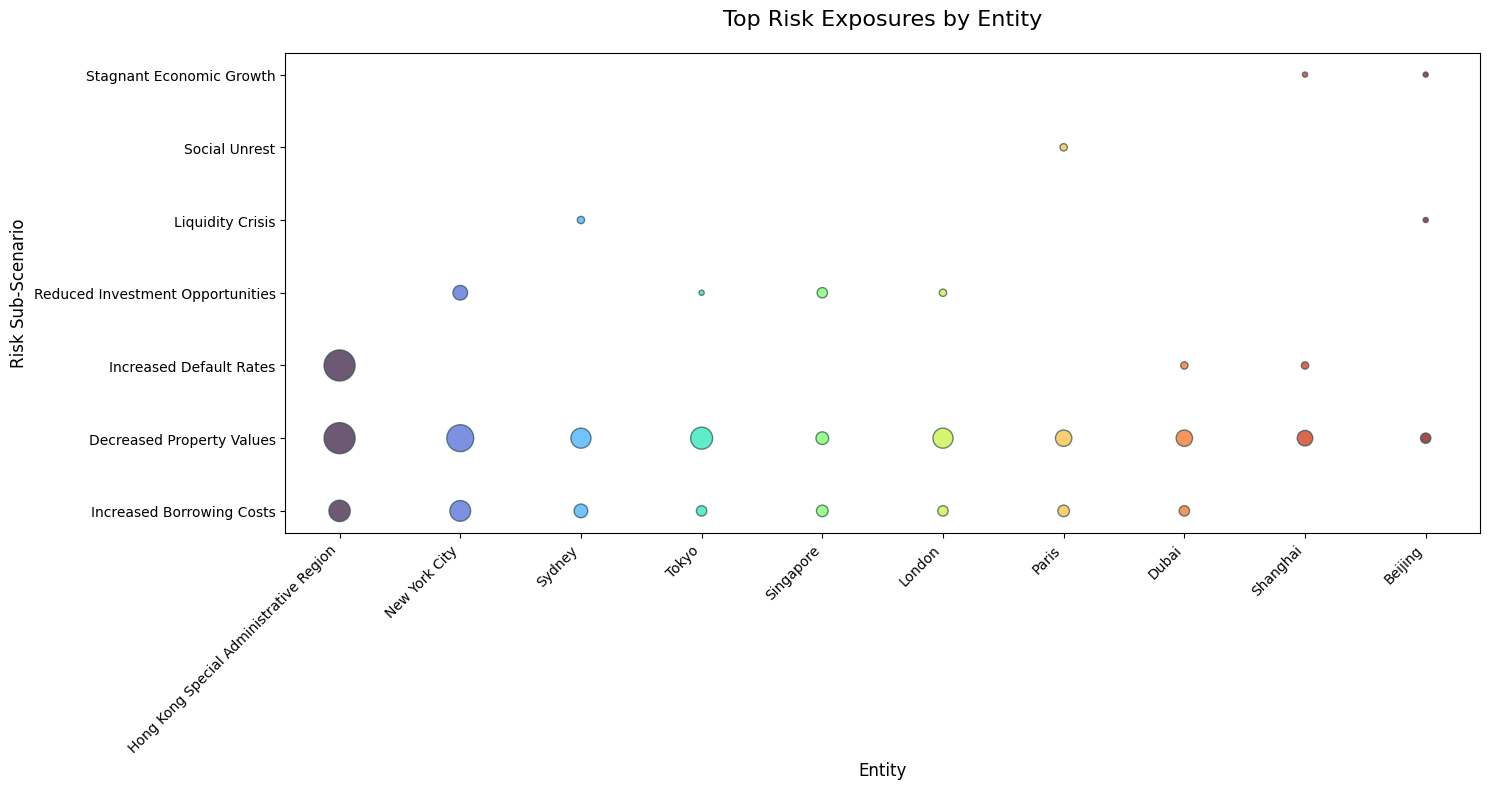

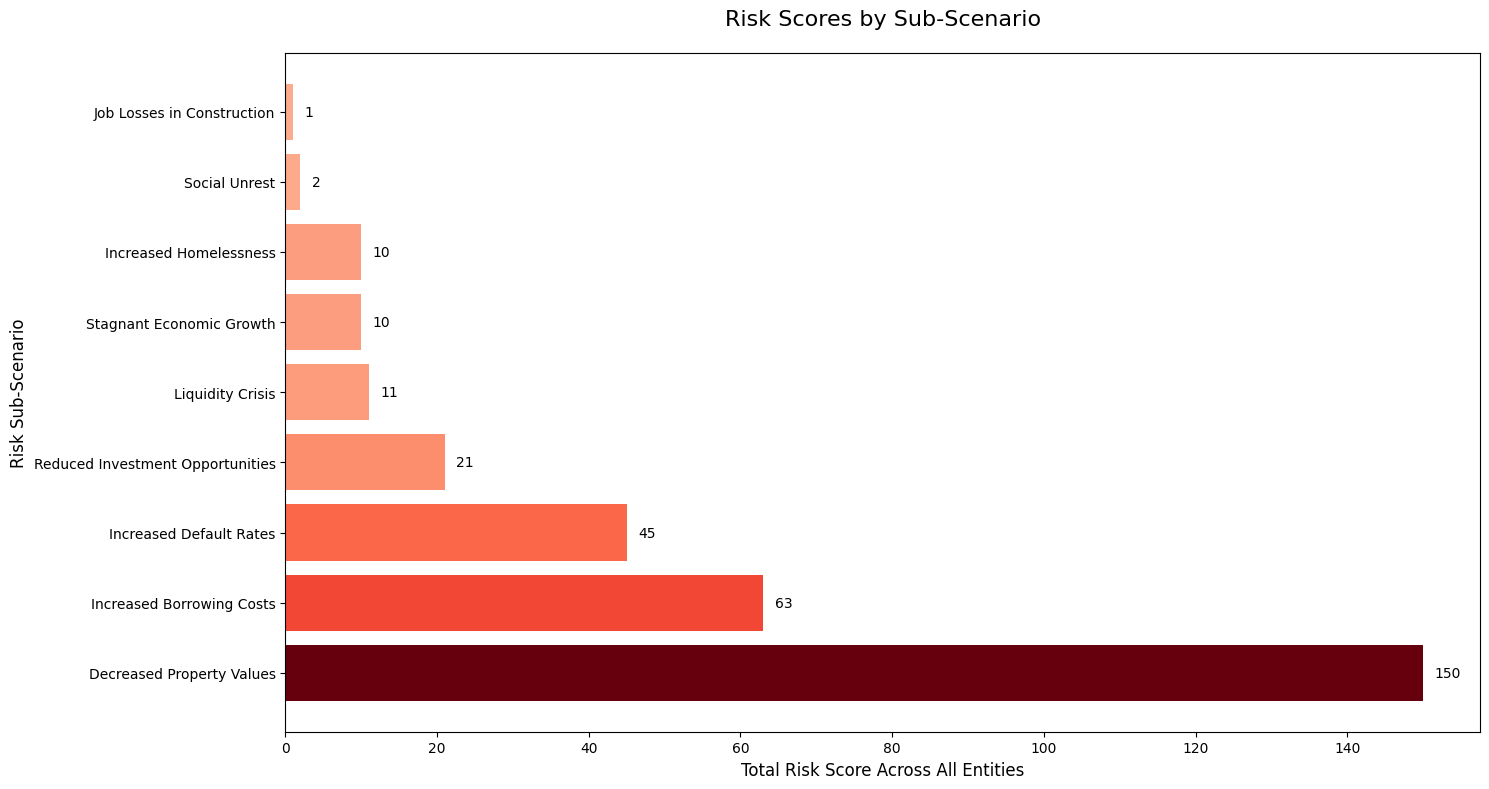

In [79]:
from src.visualization_tool import display_risk_figures_cookbooks

display_risk_figures_cookbooks(df_entity, interactive=False, n_entities=10)